In [1]:
url = 'https://raw.githubusercontent.com/dana-fatemeh/Final-ML-Project/main/Data/train.csv'

import pandas as pd

data = pd.read_csv(url)


In [2]:
data

,Id,MSSubClass,MSZoning,LotFrontage,LotArea,Street,Alley,LotShape,LandContour,Utilities,...,PoolArea,PoolQC,Fence,MiscFeature,MiscVal,MoSold,YrSold,SaleType,SaleCondition,SalePrice
0,1,60,RL,65.0,8450,Pave,NaN,Reg,Lvl,AllPub,...,0,NaN,NaN,NaN,0,2,2008,WD,Normal,208500
1,2,20,RL,80.0,9600,Pave,NaN,Reg,Lvl,AllPub,...,0,NaN,NaN,NaN,0,5,2007,WD,Normal,181500
2,3,60,RL,68.0,11250,Pave,NaN,IR1,Lvl,AllPub,...,0,NaN,NaN,NaN,0,9,2008,WD,Normal,223500
3,4,70,RL,60.0,9550,Pave,NaN,IR1,Lvl,AllPub,...,0,NaN,NaN,NaN,0,2,2006,WD,Abnorml,140000
4,5,60,RL,84.0,14260,Pave,NaN,IR1,Lvl,AllPub,...,0,NaN,NaN,NaN,0,12,2008,WD,Normal,250000
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1455,1456,60,RL,62.0,7917,Pave,NaN,Reg,Lvl,AllPub,...,0,NaN,NaN,NaN,0,8,2007,WD,Normal,175000
1456,1457,20,RL,85.0,13175,Pave,NaN,Reg,Lvl,AllPub,...,0,NaN,MnPrv,NaN,0,2,2010,WD,Normal,210000
1457,1458,70,RL,66.0,9042,Pave,NaN,Reg,Lvl,AllPub,...,0,NaN,GdPrv,Shed,2500,5,2010,WD,Normal,266500
1458,1459,20,RL,68.0,9717,Pave,NaN,Reg,Lvl,AllPub,...,0,NaN,NaN,NaN,0,4,2010,WD,Normal,142125


In [3]:
data = data.drop(columns=['Id'])

data['Has_Alley'] = data['Alley'].notna().astype(int)
data = data.drop(columns=['Alley'])

data['LotFrontage'] = data['LotFrontage'].fillna(0)
data['MasVnrArea'] = data['MasVnrArea'].fillna(0)

# MasVnrType: Masonry veneer type
# BsmtQual: Evaluates the height of the basement
# BsmtCond: Evaluates the general condition of the basement
# BsmtExposure: Refers to walkout or garden level walls
# BsmtFinType1: Rating of basement finished area
# BsmtFinType2: Rating of basement finished area (if multiple types)
# FireplaceQu: Fireplace quality
# GarageType: Garage location
# GarageFinish: Interior finish of the garage
# GarageQual: Garage quality
# GarageCond: Garage condition
# PoolQC: Pool quality
# Fence: Fence quality
# MiscFeature: Miscellaneous feature not covered in other categories

none_cols = ['MasVnrType','BsmtQual','BsmtCond','BsmtExposure','BsmtFinType1','BsmtFinType2',
             'FireplaceQu','GarageType','GarageFinish','GarageQual','GarageCond','PoolQC','Fence','MiscFeature']

for col in none_cols:
    data[col] = data[col].fillna('None')

data['GarageYrBlt'] = data['GarageYrBlt'].fillna(0)
data['GarageYrBlt'] = data['GarageYrBlt'].fillna(0)
data['Electrical'] = data['Electrical'].fillna(0)

qual_rate = {'Ex':5, 'Gd':4, 'TA':3, 'Fa':2, 'Po':1, 'None':0} # Maybe change None to -1
ord_cols = ['ExterQual','ExterCond','BsmtQual','BsmtCond','HeatingQC','KitchenQual','FireplaceQu','GarageQual','GarageCond','PoolQC']
for col in ord_cols:
    data[col+'_ord'] = data[col].map(qual_rate)
    data = data.drop(columns=[col])

data['LandContour'] = data['LandContour'].map({'Lvl':2, 'Bnk':3, 'HLS':4, 'Low':1}) # Maybe Change
data['LandSlope'] = data['LandSlope'].map({'Gtl':1, 'Mod':2, 'Sev':5})
data['BsmtExposure'] = data['BsmtExposure'].map({'Gd':10, 'Av':6, 'Mn':3, 'No':1, 'None':0})
data['BsmtFinType1'] = data['BsmtFinType1'].map({'GLQ':10, 'ALQ':7, 'BLQ':3, 'Rec':5, 'LwQ':2, 'Unf':1, 'None':0})
data['BsmtFinType2'] = data['BsmtFinType2'].map({'GLQ':10, 'ALQ':7, 'BLQ':3, 'Rec':5, 'LwQ':2, 'Unf':1, 'None':0})
data['CentralAir'] = data['CentralAir'].map({'Y':1, 'N':0})
data['Electrical'] = data['Electrical'].map({'SBrkr':10, 'FuseA':7, 'FuseF':3, 'FuseP':1, 'Mix':5})
data['Functional'] = data['Functional'].map({'Typ':10, 'Min1':9, 'Min2':8, 'Mod':5, 'Maj1':3, 'Maj2':2, 'Sev':1, 'Sal':0})
data['GarageFinish'] = data['GarageFinish'].map({'Fin':5, 'RFn':2, 'Unf':1, 'None':0})
data['Fence'] = data['Fence'].map({'GdPrv':5, 'MnPrv':3, 'GdWo':2, 'MnWw':1, 'None':0})

data = data.drop(columns=['Utilities']) # Maybe Ordinal


categorical_cols = ['MSZoning','Street','LotShape','LotConfig','Neighborhood',
                'Condition1','Condition2','BldgType','HouseStyle','RoofStyle','RoofMatl','Exterior1st','Exterior2nd','MasVnrType',
                'Foundation','Heating','CentralAir','GarageType','PavedDrive','MiscFeature',
                'SaleType','SaleCondition']

data = pd.get_dummies(data, columns=[col for col in categorical_cols], dtype=int)


data['TotalBathrooms'] = data['FullBath'] + 0.5*data['HalfBath'] + data['BsmtFullBath'] + 0.5*data['BsmtHalfBath']
data['Age'] = 2009 - data['YearBuilt']
data['RemodAge'] = 2009 - data['YearRemodAdd']
data['IsRemodeled'] = (data['YearBuilt'] != data['YearRemodAdd']).astype(int)
data['GoodTotalSF'] = data['TotalBsmtSF'] + data['1stFlrSF'] + data['WoodDeckSF'] + data['OpenPorchSF'] + data['2ndFlrSF'] - data['LowQualFinSF']
data['TotalSF'] = data['TotalBsmtSF'] + data['1stFlrSF'] + data['2ndFlrSF'] + data['WoodDeckSF'] + data['OpenPorchSF']


data

,MSSubClass,LotFrontage,LotArea,LandContour,LandSlope,OverallQual,OverallCond,YearBuilt,YearRemodAdd,MasVnrArea,...,SaleCondition_Alloca,SaleCondition_Family,SaleCondition_Normal,SaleCondition_Partial,TotalBathrooms,Age,RemodAge,IsRemodeled,GoodTotalSF,TotalSF
0,60,65.0,8450,2,1,7,5,2003,2003,196.0,...,0,0,1,0,3.5,6,6,0,2627,2627
1,20,80.0,9600,2,1,6,8,1976,1976,0.0,...,0,0,1,0,2.5,33,33,0,2822,2822
2,60,68.0,11250,2,1,7,5,2001,2002,162.0,...,0,0,1,0,3.5,8,7,1,2748,2748
3,70,60.0,9550,2,1,7,5,1915,1970,0.0,...,0,0,0,0,2.0,94,39,1,2508,2508
4,60,84.0,14260,2,1,8,5,2000,2000,350.0,...,0,0,1,0,3.5,9,9,0,3619,3619
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1455,60,62.0,7917,2,1,6,5,1999,2000,0.0,...,0,0,1,0,2.5,10,9,1,2640,2640
1456,20,85.0,13175,2,1,6,6,1978,1988,119.0,...,0,0,1,0,3.0,31,21,1,3964,3964
1457,70,66.0,9042,2,1,7,9,1941,2006,0.0,...,0,0,1,0,2.0,68,3,1,3552,3552
1458,20,68.0,9717,2,1,5,6,1950,1996,0.0,...,0,0,1,0,2.0,59,13,1,2522,2522


In [4]:
print(len(data))

1460


In [5]:
data.info()


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1460 entries, 0 to 1459
Columns: 227 entries, MSSubClass to TotalSF
dtypes: float64(5), int64(222)
memory usage: 2.5 MB


In [6]:
data.describe()


,MSSubClass,LotFrontage,LotArea,LandContour,LandSlope,OverallQual,OverallCond,YearBuilt,YearRemodAdd,MasVnrArea,...,SaleCondition_Alloca,SaleCondition_Family,SaleCondition_Normal,SaleCondition_Partial,TotalBathrooms,Age,RemodAge,IsRemodeled,GoodTotalSF,TotalSF
count,1460.000000,1460.000000,1460.000000,1460.000000,1460.000000,1460.000000,1460.000000,1460.000000,1460.000000,1460.000000,...,1460.000000,1460.000000,1460.000000,1460.000000,1460.000000,1460.000000,1460.000000,1460.000000,1460.000000,1460.000000
mean,56.897260,57.623288,10516.828082,2.086986,1.080137,6.099315,5.575342,1971.267808,1984.865753,103.117123,...,0.008219,0.013699,0.820548,0.085616,2.210616,37.732192,24.134247,0.476712,2702.108904,2707.953425
std,42.300571,34.664304,9981.264932,0.444256,0.425074,1.382997,1.112799,30.202904,20.645407,180.731373,...,0.090317,0.116277,0.383862,0.279893,0.785399,30.202904,20.645407,0.499629,890.943383,889.920817
min,20.000000,0.000000,1300.000000,1.000000,1.000000,1.000000,1.000000,1872.000000,1950.000000,0.000000,...,0.000000,0.000000,0.000000,0.000000,1.000000,-1.000000,-1.000000,0.000000,334.000000,334.000000
25%,20.000000,42.000000,7553.500000,2.000000,1.000000,5.000000,5.000000,1954.000000,1967.000000,0.000000,...,0.000000,0.000000,1.000000,0.000000,2.000000,9.000000,5.000000,0.000000,2080.000000,2082.000000
50%,50.000000,63.000000,9478.500000,2.000000,1.000000,6.000000,5.000000,1973.000000,1994.000000,0.000000,...,0.000000,0.000000,1.000000,0.000000,2.000000,36.000000,15.000000,0.000000,2596.000000,2599.000000
75%,70.000000,79.000000,11601.500000,2.000000,1.000000,7.000000,6.000000,2000.000000,2004.000000,164.250000,...,0.000000,0.000000,1.000000,0.000000,2.500000,55.000000,42.000000,1.000000,3203.750000,3203.750000
max,190.000000,313.000000,215245.000000,4.000000,5.000000,10.000000,9.000000,2010.000000,2010.000000,1600.000000,...,1.000000,1.000000,1.000000,1.000000,6.000000,137.000000,59.000000,1.000000,12258.000000,12258.000000


In [7]:
data.dtypes

,0
MSSubClass,int64
LotFrontage,float64
LotArea,int64
LandContour,int64
LandSlope,int64
...,...
Age,int64
RemodAge,int64
IsRemodeled,int64
GoodTotalSF,int64


In [8]:
# Separate into numerical features that don't need preprocessing, and categorical features that need to be transformed
num_feat = data.select_dtypes(include=['int64','float64']).columns
# print(num_feat[30:50])
# cat_feat = data.select_dtypes(include=['object','bool']).columns

In [9]:
import matplotlib.pyplot as plt
import matplotlib.colors as mcolors
%matplotlib inline
import seaborn as sns
import plotly.express as px

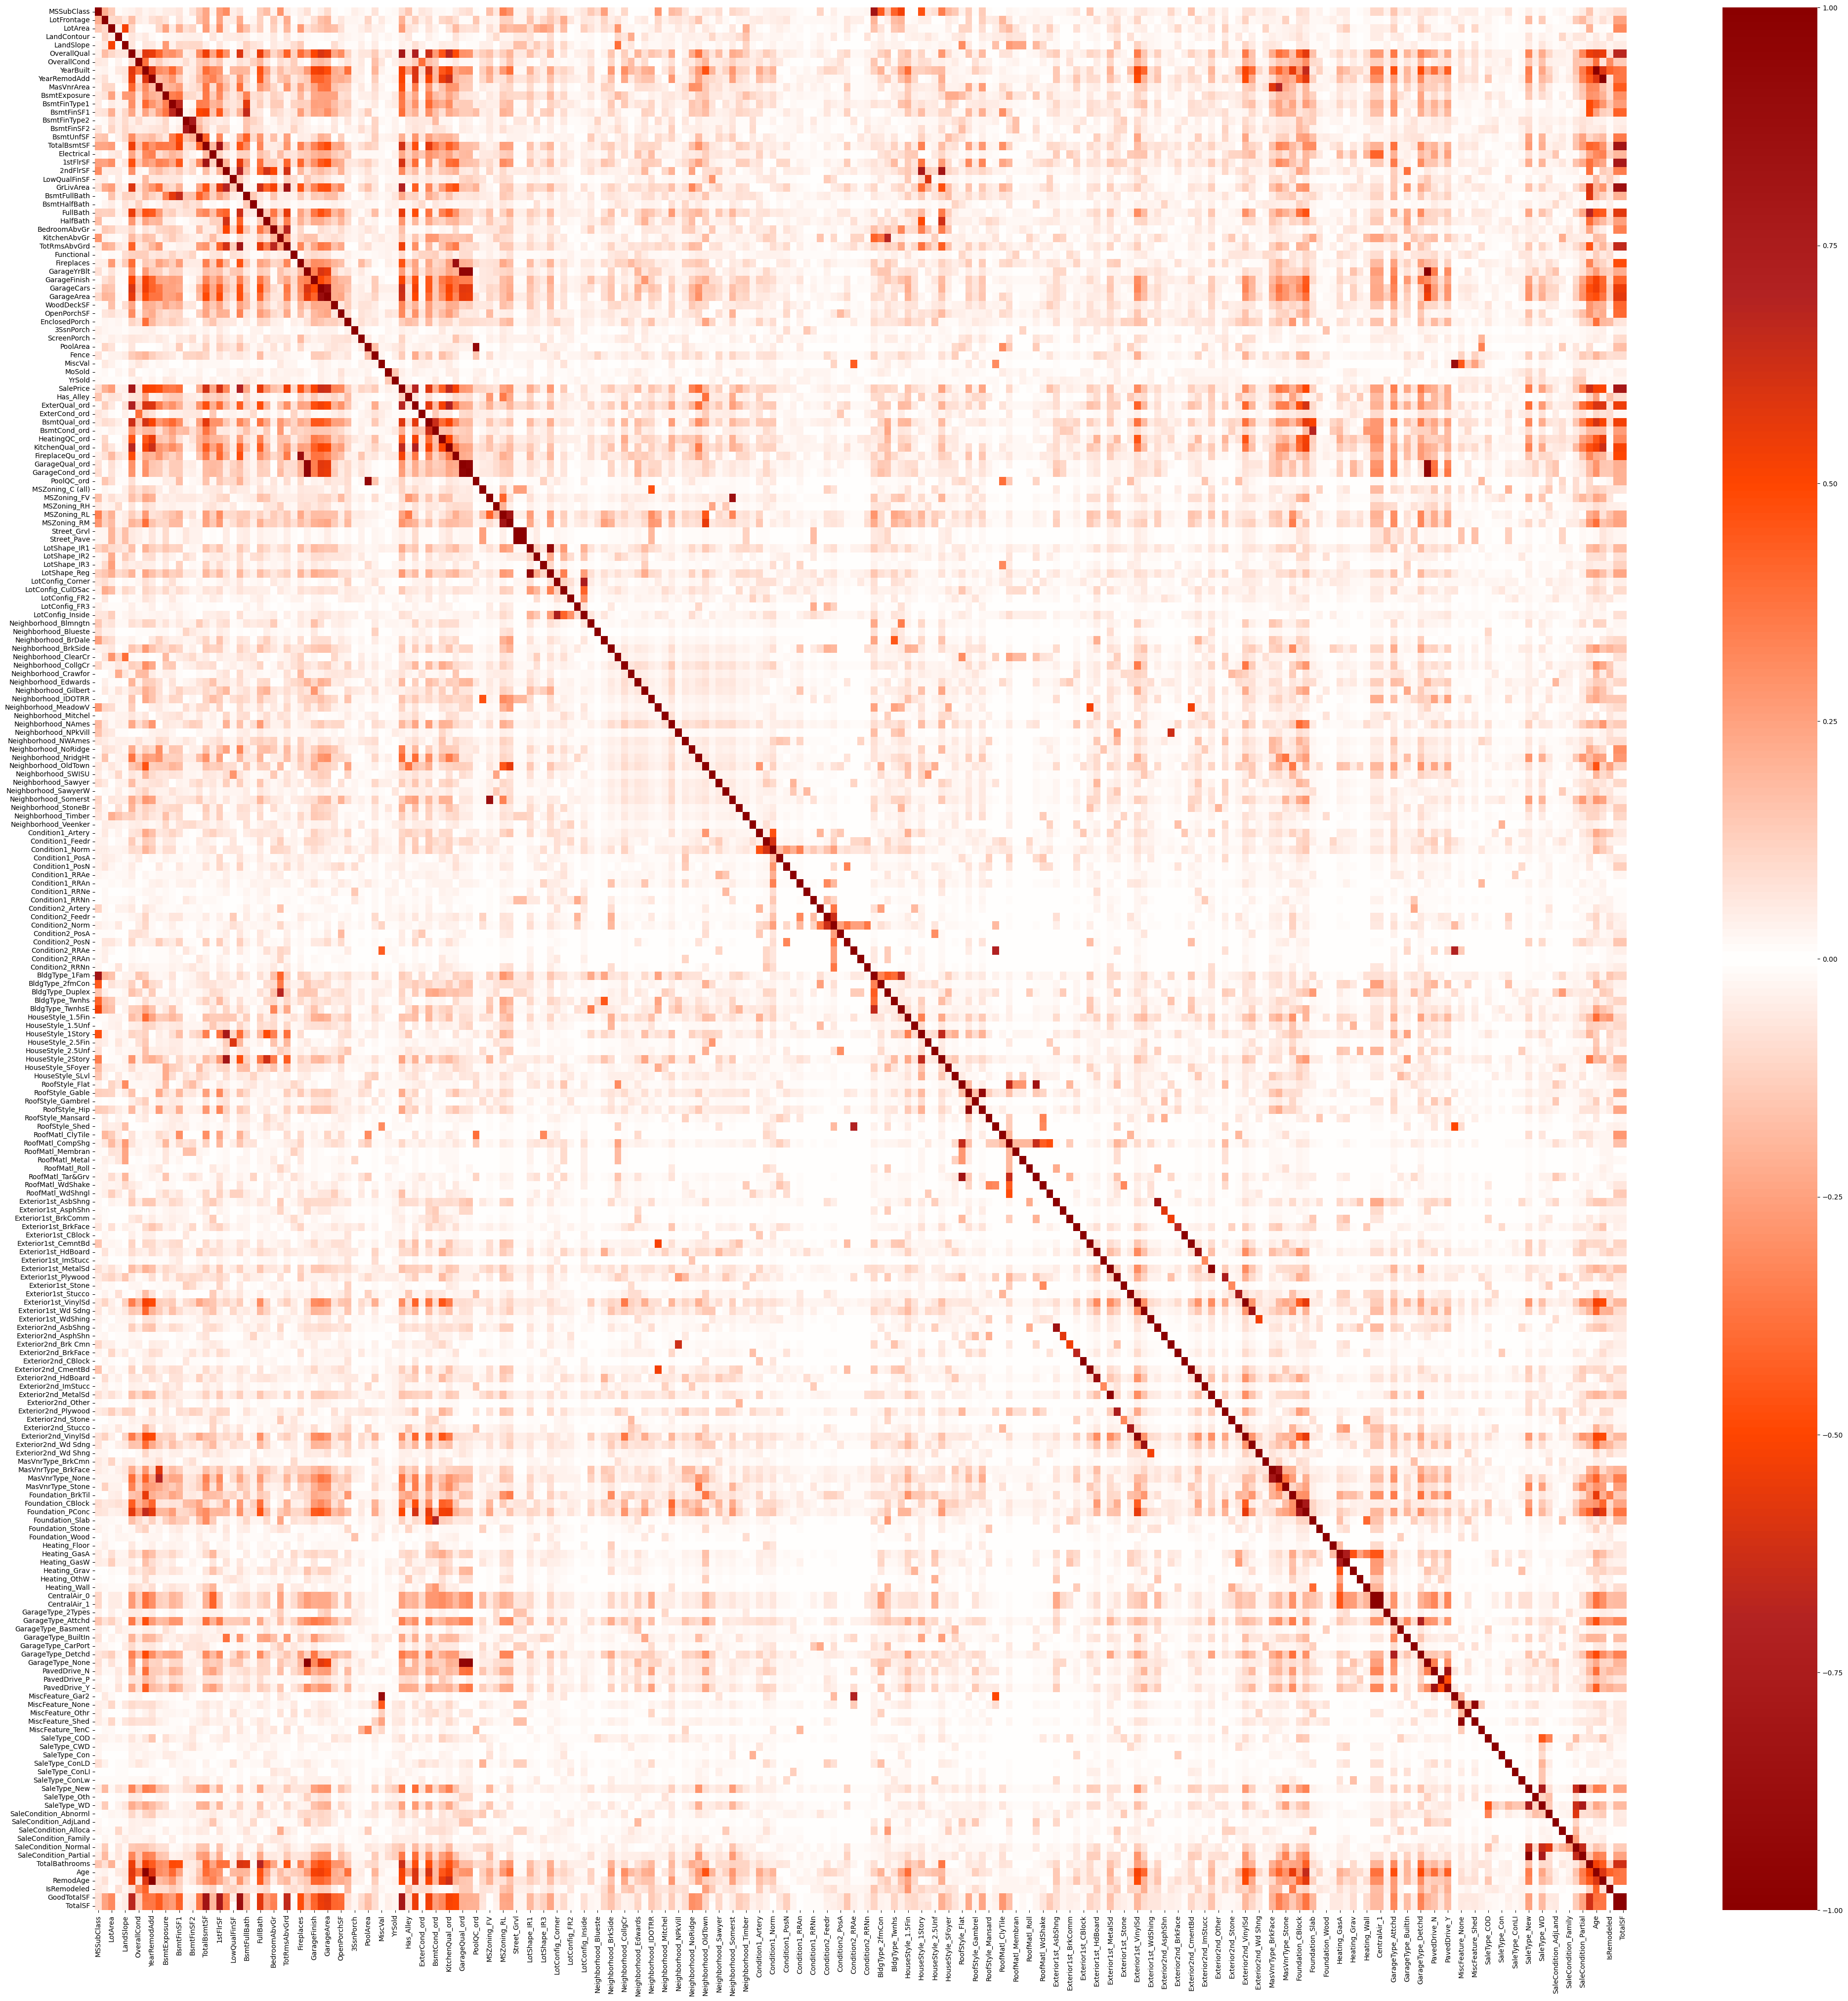

In [10]:
plt.figure(figsize=(50,50))
cor = data[num_feat].corr()

# Custom edits to colormap to show 0 "no correlation" as white, and both correlation extremes as equal colors
colors = ["darkred", "firebrick", "orangered", "white", "orangered", "firebrick", "darkred"]
nodes = [0.0, 0.15, 0.25, 0.5, 0.75, 0.85, 1.0]
double_prawn = mcolors.LinearSegmentedColormap.from_list("double_prawn", list(zip(nodes, colors)))
fit_colors = mcolors.TwoSlopeNorm(vmin=-1.0, vcenter=0, vmax=1.0)

sns.heatmap(cor,cmap=double_prawn, norm=fit_colors)
plt.show()

In [11]:
# sns.pairplot(data[num_feat], height=1.7, aspect=1)

In [12]:
# Axis Prep
import torch
import torch.nn as nn
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.impute import SimpleImputer
from sklearn.metrics import mean_absolute_error, r2_score, mean_squared_error
import time
from tabulate import tabulate

# Set 'SalePrice' as y
y = data['SalePrice'] if 'SalePrice' in data.columns else None
X = data.drop(columns=['SalePrice']) if 'SalePrice' in data.columns else data.copy()


if y is not None:
    # Impute missing values (if any)
    imputer = SimpleImputer(strategy='most_frequent')
    X_imputed = imputer.fit_transform(X)
    # Scale features
    scaler = StandardScaler()
    X_scaled = scaler.fit_transform(X_imputed)
    # Train/test split
    X_train_hierarchical, X_test_hierarchical, y_train_hierarchical, y_test_hierarchical = train_test_split(X_scaled, y.values, test_size=0.2, random_state=1234)

    X_total = X_train_hierarchical
    y_total = y_train_hierarchical

    X_train, X_test, y_train, y_test = train_test_split(X_total, y_total, test_size=0.2, random_state=1234)

In [13]:
import numpy as np
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

def model_eva_sklearn(XTrain, XTest, yTrain, yTest, model):
    yTrain_pred = model.predict(XTrain)
    yTest_pred = model.predict(XTest)

    MAE_train = mean_absolute_error(yTrain, yTrain_pred)
    MSE_train = mean_squared_error(yTrain, yTrain_pred)
    RMSE_train = np.sqrt(MSE_train)
    R2_train = r2_score(yTrain, yTrain_pred)

    MAE_test = mean_absolute_error(yTest, yTest_pred)
    MSE_test = mean_squared_error(yTest, yTest_pred)
    RMSE_test = np.sqrt(MSE_test)
    R2_test = r2_score(yTest, yTest_pred)

    return MAE_train, MSE_train, RMSE_train, R2_train, MAE_test, MSE_test, RMSE_test, R2_test

In [18]:
from sklearn.tree import DecisionTreeRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
from tabulate import tabulate
import numpy as np

# decision tree model with no hyperparameters to show overfitting
dt_model_overfit = DecisionTreeRegressor(
    random_state=1234
)

# train
dt_model_overfit.fit(X_train, y_train)

# evaluate
MAE_train_dt_overfit, MSE_train_dt_overfit, RMSE_train_dt_overfit, R2_train_dt_overfit, \
MAE_test_dt_overfit, MSE_test_dt_overfit, RMSE_test_dt_overfit, R2_test_dt_overfit = model_eva_sklearn(
    X_train, X_test, y_train, y_test, dt_model_overfit
)

results = []

results.append([
    "DecisionTree Overfit",
    MAE_train_dt_overfit, MSE_train_dt_overfit, RMSE_train_dt_overfit, R2_train_dt_overfit,
    MAE_test_dt_overfit, MSE_test_dt_overfit, RMSE_test_dt_overfit, R2_test_dt_overfit
])

print(tabulate(
    results,
    headers=[
        "Model", "Training MAE", "Training MSE", "Training RMSE", "Training R^2",
        "Test MAE", "Test MSE", "Test RMSE", "Test R^2"
    ],
    tablefmt="grid"
))

+----------------------+----------------+----------------+-----------------+----------------+------------+-------------+-------------+------------+
| Model                |   Training MAE |   Training MSE |   Training RMSE |   Training R^2 |   Test MAE |    Test MSE |   Test RMSE |   Test R^2 |
+======================+================+================+=================+================+============+=============+=============+============+
| DecisionTree Overfit |              0 |              0 |               0 |              1 |    26468.1 | 1.81442e+09 |       42596 |   0.717262 |
+----------------------+----------------+----------------+-----------------+----------------+------------+-------------+-------------+------------+


In [19]:
from sklearn.tree import DecisionTreeRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
from tabulate import tabulate
import numpy as np

# decision tree model with hyperparameters to prevent overfitting
dt_model = DecisionTreeRegressor(
    max_depth=20, 
    min_samples_split=20, 
    min_samples_leaf=10,
    random_state=1234
)

# train
dt_model.fit(X_train, y_train)

# evaluate
MAE_train_dt, MSE_train_dt, RMSE_train_dt, R2_train_dt, \
MAE_test_dt, MSE_test_dt, RMSE_test_dt, R2_test_dt = model_eva_sklearn(
    X_train, X_test, y_train, y_test, dt_model
)



results.append([
    "DecisionTree",
    MAE_train_dt, MSE_train_dt, RMSE_train_dt, R2_train_dt,
    MAE_test_dt, MSE_test_dt, RMSE_test_dt, R2_test_dt
])

print(tabulate(
    results,
    headers=[
        "Model", "Training MAE", "Training MSE", "Training RMSE", "Training R^2",
        "Test MAE", "Test MSE", "Test RMSE", "Test R^2"
    ],
    tablefmt="grid"
))

+----------------------+----------------+----------------+-----------------+----------------+------------+-------------+-------------+------------+
| Model                |   Training MAE |   Training MSE |   Training RMSE |   Training R^2 |   Test MAE |    Test MSE |   Test RMSE |   Test R^2 |
+======================+================+================+=================+================+============+=============+=============+============+
| DecisionTree Overfit |            0   |    0           |             0   |       1        |    26468.1 | 1.81442e+09 |     42596   |   0.717262 |
+----------------------+----------------+----------------+-----------------+----------------+------------+-------------+-------------+------------+
| DecisionTree         |        16120.6 |    7.37894e+08 |         27164.2 |       0.886983 |    22236.8 | 1.0921e+09  |     33046.9 |   0.82982  |
+----------------------+----------------+----------------+-----------------+----------------+------------+------

In [20]:
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
from tabulate import tabulate
import numpy as np

# random forest model
rf_model = RandomForestRegressor(
    n_estimators=200, # number of trees in the forest
    random_state=1234, 
)

# train
rf_model.fit(X_train, y_train)

# evaluate
MAE_train_rf, MSE_train_rf, RMSE_train_rf, R2_train_rf, \
MAE_test_rf, MSE_test_rf, RMSE_test_rf, R2_test_rf = model_eva_sklearn(
    X_train, X_test, y_train, y_test, rf_model
)


results.append([
    "RandomForest",
    MAE_train_rf, MSE_train_rf, RMSE_train_rf, R2_train_rf,
    MAE_test_rf, MSE_test_rf, RMSE_test_rf, R2_test_rf
])

print(tabulate(
    results,
    headers=[
        "Model", "Training MAE", "Training MSE", "Training RMSE", "Training R^2",
        "Test MAE", "Test MSE", "Test RMSE", "Test R^2"
    ],
    tablefmt="grid"
))

+----------------------+----------------+----------------+-----------------+----------------+------------+-------------+-------------+------------+
| Model                |   Training MAE |   Training MSE |   Training RMSE |   Training R^2 |   Test MAE |    Test MSE |   Test RMSE |   Test R^2 |
+======================+================+================+=================+================+============+=============+=============+============+
| DecisionTree Overfit |           0    |    0           |             0   |       1        |    26468.1 | 1.81442e+09 |     42596   |   0.717262 |
+----------------------+----------------+----------------+-----------------+----------------+------------+-------------+-------------+------------+
| DecisionTree         |       16120.6  |    7.37894e+08 |         27164.2 |       0.886983 |    22236.8 | 1.0921e+09  |     33046.9 |   0.82982  |
+----------------------+----------------+----------------+-----------------+----------------+------------+------